In [15]:
import pandas as pd
import numpy as np
import joblib
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score,roc_auc_score,classification_report

In [10]:
df_train=pd.read_csv("../../data/processed/train_engineered.csv")
df_val=pd.read_csv("../../data/processed/val_engineered.csv")
df_test=pd.read_csv("../../data/processed/test_engineered.csv")

FEATURE_COLS=joblib.load("../../data/processed/feature_cols.pkl")

X_train=df_train[FEATURE_COLS].fillna(-999)
y_train=df_train['isFraud']
X_val=df_val[FEATURE_COLS].fillna(-999)
y_val=df_val['isFraud']
X_test=df_test[FEATURE_COLS].fillna(-999)
y_test=df_test['isFraud']

print(f"Train: {X_train.shape} | Fraud: {y_train.sum()}")
print(f"Val:   {X_val.shape}   | Fraud: {y_val.sum()}")
print(f"Test:  {X_test.shape}  | Fraud: {y_test.sum()}")

Train: (472432, 105) | Fraud: 16599
Val:   (59054, 105)   | Fraud: 1851
Test:  (59054, 105)  | Fraud: 2213


In [16]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("fraud-detection-ieee-cis")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1780920421470, experiment_id='1', last_update_time=1780920421470, lifecycle_stage='active', name='fraud-detection-ieee-cis', tags={}, trace_location=None, workspace='default'>

In [41]:
with mlflow.start_run(run_name='random_forest_105features'):
    mlflow.log_param('model','RandomForest')
    mlflow.log_param('n_estimators',200)
    mlflow.log_param('class_weight','balanced')
    mlflow.log_param('feature_count',len(FEATURE_COLS))
    rf=RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=35,n_jobs=-1)
    rf.fit(X_train,y_train)
    y_prob_train_rf=rf.predict_proba(X_train)[:,1]
    y_prob_val_rf=rf.predict_proba(X_val)[:,1]
    train_pr=average_precision_score(y_train,y_prob_train_rf)
    val_pr=average_precision_score(y_val,y_prob_val_rf)
    val_roc=roc_auc_score(y_val,y_prob_val_rf)
    mlflow.log_metric('train_pr_auc',train_pr)
    mlflow.log_metric('val_pr_auc',val_pr)
    mlflow.log_metric('val_roc_auc',val_roc)
    mlflow.sklearn.log_model(rf,'random_forest')
    print(f"RF Train PR: {train_pr:.4f} | Val PR: {val_pr:.4f} | Val ROC: {val_roc:.4f}")
    print(f"RF Overfit gap: {train_pr-val_pr:.4f}")

2026/06/08 17:38:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:38:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RF Train PR: 1.0000 | Val PR: 0.5829 | Val ROC: 0.9187
RF Overfit gap: 0.4171
🏃 View run random_forest_105features at: http://127.0.0.1:5000/#/experiments/1/runs/77a03c013a734d1097ae7a4131fc519b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [42]:
n_neg=(y_train==0).sum()
n_pos=(y_train==1).sum()
spw=n_neg / n_pos
print(f"scale_pos_weight: {spw:.1f}")
with mlflow.start_run(run_name="xgboost_105features"):
    mlflow.log_param("model","xgboost")
    mlflow.log_param("scale_pos_weight",round(spw,1))
    mlflow.log_param("n_estimators",500)
    mlflow.log_param("max_depth",6)
    mlflow.log_param("learning_rate",0.05)
    mlflow.log_param("feature_count",len(FEATURE_COLS))
    xgb=XGBClassifier(n_estimators=500,scale_pos_weight=spw,max_depth=6,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=35,eval_metric='aucpr',
                      early_stopping_rounds=30,verbosity=0,tree_method='hist',n_jobs=-1)
    xgb.fit(X_train,y_train,eval_set=[(X_val,y_val)],verbose=100)
    y_prob_train_xgb=xgb.predict_proba(X_train)[:,1]
    y_prob_val_xgb=xgb.predict_proba(X_val)[:,1]
    train_pr=average_precision_score(y_train,y_prob_train_xgb)
    val_pr=average_precision_score(y_val,y_prob_val_xgb)
    val_roc=roc_auc_score(y_val,y_prob_val_xgb)
    mlflow.log_metric("train_pr_auc",train_pr)
    mlflow.log_metric("val_pr_auc",val_pr)
    mlflow.log_metric("val_roc_auc",val_roc)
    mlflow.sklearn.log_model(xgb,"xgboost")
    print(f"XGB Train PR: {train_pr:.4f} | Val PR: {val_pr:.4f} | Val ROC: {val_roc:.4f}")
    print(f"XGB Overfit gap: {train_pr-val_pr:.4f}")


scale_pos_weight: 27.5
[0]	validation_0-aucpr:0.30932
[100]	validation_0-aucpr:0.46198
[200]	validation_0-aucpr:0.48793
[300]	validation_0-aucpr:0.50316
[400]	validation_0-aucpr:0.51833
[499]	validation_0-aucpr:0.52819


2026/06/08 17:39:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 17:39:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGB Train PR: 0.7785 | Val PR: 0.5283 | Val ROC: 0.9192
XGB Overfit gap: 0.2502
🏃 View run xgboost_105features at: http://127.0.0.1:5000/#/experiments/1/runs/cbe2325deb0645cc97b87f1993e5a9e1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


#### Choosing RF as a better model

In [11]:
rf=RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=35,n_jobs=-1)
rf.fit(X_train,y_train)
y_prob_train_rf=rf.predict_proba(X_train)[:,1]
y_prob_val_rf=rf.predict_proba(X_val)[:,1]
train_pr=average_precision_score(y_train,y_prob_train_rf)
val_pr=average_precision_score(y_val,y_prob_val_rf)
val_roc=roc_auc_score(y_val,y_prob_val_rf)
print(f"RF Train PR: {train_pr:.4f} | Val PR: {val_pr:.4f} | Val ROC: {val_roc:.4f}")
print(f"RF Overfit gap: {train_pr-val_pr:.4f}")

RF Train PR: 1.0000 | Val PR: 0.5829 | Val ROC: 0.9187
RF Overfit gap: 0.4171


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

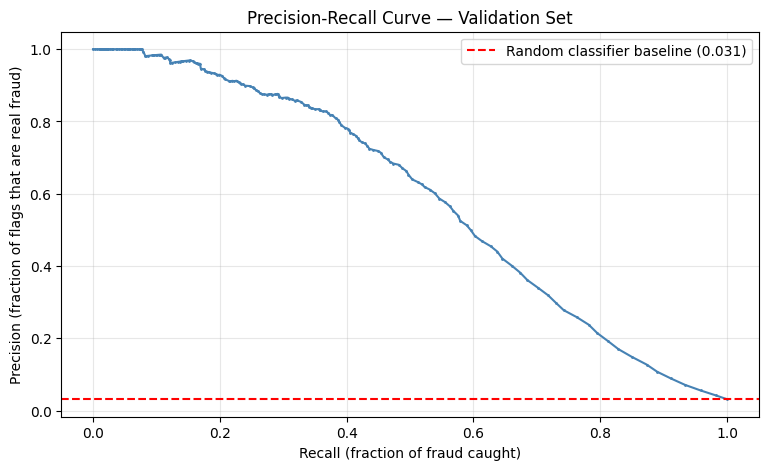

F1-optimal threshold: 0.1700
At that threshold — Precision: 0.6117 | Recall: 0.5311
Threshold 0.30: Precision 0.780, Recall 0.401
Threshold 0.40: Precision 0.846, Recall 0.333
Threshold 0.50: Precision 0.879, Recall 0.263
Threshold 0.17: Precision 0.612, Recall 0.531
Threshold 0.60: Precision 0.928, Recall 0.196
Threshold 0.70: Precision 0.966, Recall 0.138


In [ ]:
precisions,recalls,thresholds=precision_recall_curve(y_val,y_prob_val_rf)

# Plotting the full PR curve
plt.figure(figsize=(9,5))
plt.plot(recalls,precisions,marker='.',markersize=2,color='steelblue')
plt.xlabel('Recall (fraction of fraud caught)')
plt.ylabel('Precision (fraction of flags that are real fraud)')
plt.title('Precision-Recall Curve — Validation Set')
# I'm plotting baseline: a random classifier's precision=fraud rate
plt.axhline(y=y_val.mean(),color='red',linestyle='--',
            label=f'Random classifier baseline ({y_val.mean():.3f})')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

# Finding the F1 optimal threshold
f1_scores=2*precisions*recalls/(precisions+recalls+1e-8)
best_idx=f1_scores[:-1].argmax()
best_thresh=thresholds[best_idx]

print(f"F1-optimal threshold: {best_thresh:.4f}")
print(f"At that threshold — Precision: {precisions[best_idx]:.4f} | Recall: {recalls[best_idx]:.4f}")

# Checking few candidate thresholds
for t in [0.3,0.4,0.5,best_thresh,0.6,0.7]:
    idx=np.searchsorted(thresholds, t)
    if idx<len(precisions)-1:
        print(f"Threshold {t:.2f}: Precision{precisions[idx]:.3f}, Recall {recalls[idx]:.3f}")

# Choose your threshold — write the reason in a comment
CHOSEN_THRESHOLD = best_thresh  # document why this threshold makes sense

In [ ]:
def get_fraud_risk_tier(fraud_prob):
    """
    I'm converting fraud probability into analyst-facing risk tiers.
    Thresholds are based on validation-set threshold tuning.
    """

    if fraud_prob>=0.70:
        return{
            "tier":"HIGH RISK",
            "action":"Immediate analyst review"
        }

    elif fraud_prob>=0.40:
        return{
            "tier":"ELEVATED RISK",
            "action":"Queue for analyst investigation"
        }

    elif fraud_prob>= 0.17:
        return{
            "tier":"MODERATE RISK",
            "action":"Monitor transaction"
        }

    else:
        return{
            "tier":"LOW RISK",
            "action":"No immediate action required"
        }

In [ ]:
# New session for testing so without the logging I ran this cell
y_prob_test=rf.predict_proba(X_test)[:,1]
y_pred_test=(y_prob_test>=CHOSEN_THRESHOLD).astype(int)
pr_auc_test=average_precision_score(y_test,y_prob_test)
roc_auc_test=roc_auc_score(y_test,y_prob_test)
print("Test Metrics:")
print(f"PR-AUC: {pr_auc_test:.4f}")
print(f"ROC-AUC: {roc_auc_test:.4f}")
print(f"At threshold {CHOSEN_THRESHOLD:.4f}:")
print(classification_report(y_test,y_pred_test,target_names=['legit','fraud']))

with mlflow.start_run(run_id="77a03c013a734d1097ae7a4131fc519b"):
    mlflow.log_metric("test_pr_auc",pr_auc_test)
    mlflow.log_metric("test_roc_auc",roc_auc_test)
    mlflow.log_param("chosen_threshold",round(CHOSEN_THRESHOLD,4))
    

Test Metrics:
PR-AUC: 0.5330
ROC-AUC: 0.9029
At threshold 0.1700:
              precision    recall  f1-score   support

       legit       0.98      0.99      0.98     56841
       fraud       0.60      0.50      0.54      2213

    accuracy                           0.97     59054
   macro avg       0.79      0.74      0.76     59054
weighted avg       0.97      0.97      0.97     59054

🏃 View run random_forest_105features at: http://127.0.0.1:5000/#/experiments/1/runs/77a03c013a734d1097ae7a4131fc519b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [ ]:
# Saving artifacts
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(rf, 'models/fraud_model.pkl')
joblib.dump(FEATURE_COLS, 'models/feature_cols.pkl')
joblib.dump(CHOSEN_THRESHOLD, 'models/threshold.pkl')

print("Saved: fraud_model.pkl, feature_cols.pkl, threshold.pkl")

In [19]:
import os
print(os.getcwd())

c:\Users\sathi\fraud-platform\ml-service\notebooks


In [20]:
import joblib
import os
MODEL_DIR="../../models"
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(rf, f"{MODEL_DIR}/fraud_model.pkl")
joblib.dump(FEATURE_COLS, f"{MODEL_DIR}/feature_cols.pkl")
joblib.dump(CHOSEN_THRESHOLD, f"{MODEL_DIR}/threshold.pkl")

print(f"Artifacts saved to: {os.path.abspath(MODEL_DIR)}")

Artifacts saved to: c:\Users\sathi\fraud-platform\models


In [ ]:
import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Register the XGBoost model
model_uri = f"runs:/{"77a03c013a734d1097ae7a4131fc519b"}/random_forest"
registered = mlflow.register_model(model_uri, "fraud_rf_ieee")

print(f"Registered model: {registered.name}, version: {registered.version}")

# Add description — this is what you'd see in an ML platform review
client.update_model_version(
    name="fraud_rf_ieee",
    version=registered.version,
    description=(
        f"XGBoost on IEEE-CIS. PR-AUC={pr_auc_test:.4f}. "
        f"Threshold={CHOSEN_THRESHOLD:.4f}. "
        f"Features={len(FEATURE_COLS)}. "
        f"n_={spw:.1f}."
    )
)

# Transition to production stage
client.transition_model_version_stage(
    name="fraud_xgb_ieee",
    version=registered.version,
    stage="Production"
)
print("Model transitioned to Production stage")

In [21]:
import mlflow
from mlflow.tracking import MlflowClient

In [22]:
client=MlflowClient()
run_id="77a03c013a734d1097ae7a4131fc519b"
# Register the RF model
model_uri=f"runs:/{run_id}/random_forest"
registered=mlflow.register_model(model_uri, "fraud_rf_ieee")
print(f"Registered model: {registered.name}, version: {registered.version}")

# Add description with final test metrics
client.update_model_version(
    name="fraud_rf_ieee",
    version=registered.version,
    description=(
        f"RandomForest on IEEE-CIS. Test PR-AUC={pr_auc_test:.4f}. "
        f"Test ROC-AUC={roc_auc_test:.4f}. "
        f"Threshold={CHOSEN_THRESHOLD:.4f}. "
        f"Features={len(FEATURE_COLS)}. "
        f"class_weight=balanced."
    )
)

# Transition to production stage
client.transition_model_version_stage(
    name="fraud_rf_ieee",
    version=registered.version,
    stage="Production"
)
print("Model transitioned to Production stage")

Successfully registered model 'fraud_rf_ieee'.
2026/06/11 16:20:39 WARNING mlflow.tracking._model_registry.fluent: Run with id 77a03c013a734d1097ae7a4131fc519b has no artifacts at artifact path 'random_forest', registering model based on models:/m-97b2ffbfc2d040aca14022aa49d31c23 instead
2026/06/11 16:20:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: fraud_rf_ieee, version 1


Registered model: fraud_rf_ieee, version: 1
Model transitioned to Production stage


Created version '1' of model 'fraud_rf_ieee'.
C:\Users\sathi\AppData\Local\Temp\ipykernel_16984\486007742.py:22: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(
